Target: WASP-18
Light curve downloaded successfully.


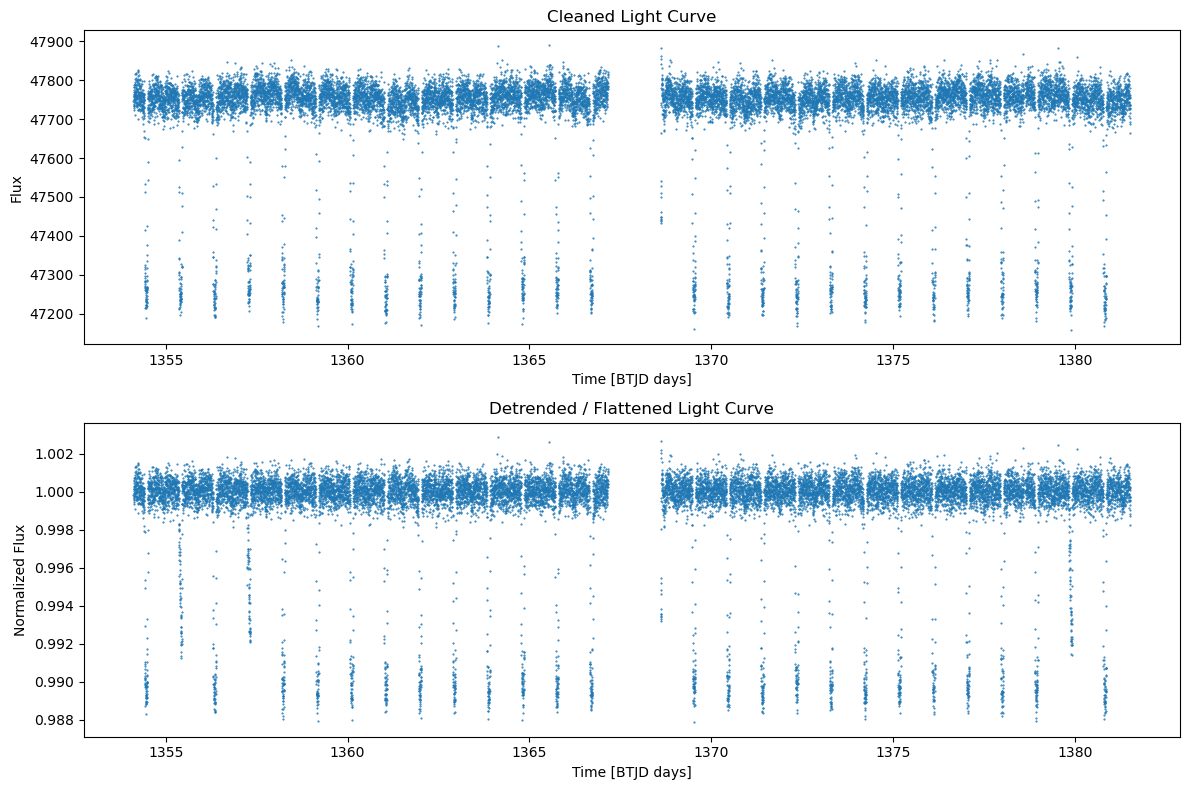


=== BLS Results ===
Best period   = 0.941488 days
Transit time  = 1354.459007 BTJD
Duration      = 0.085000 days
Depth         = 0.008970


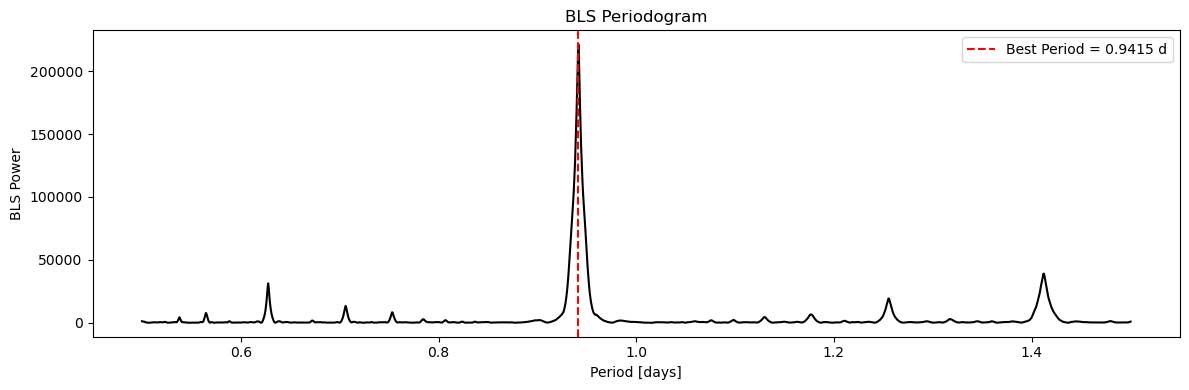

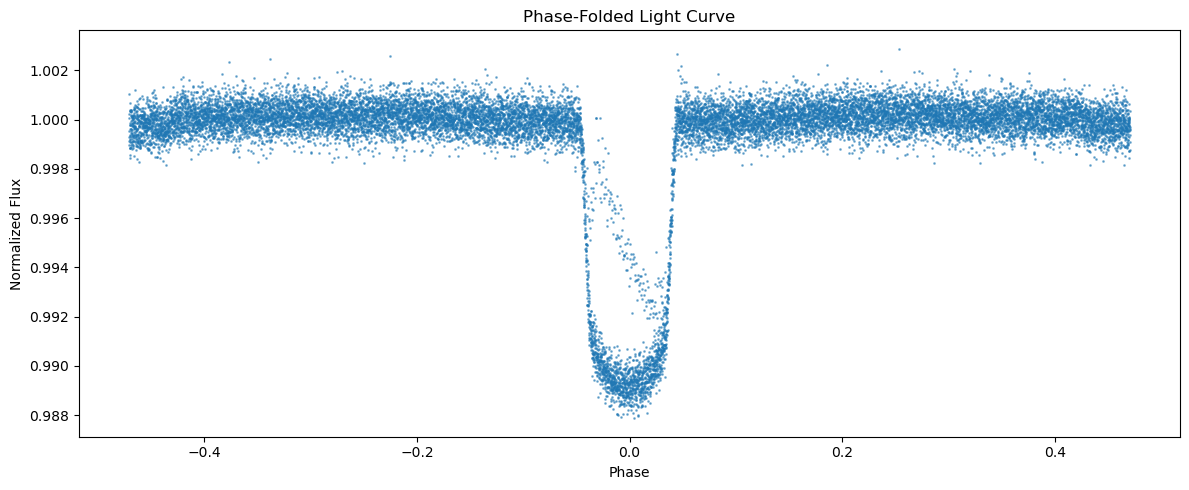


=== Transit Fit Results ===
Rp/Rs        = 0.09538 ± 0.00035
a/Rs         = 3.62945 ± 0.06239
Inclination  = 83.74118 ± 0.74137 deg
t0 shift     = -0.001367 ± 0.000066 days
Transit depth≈ 0.009097


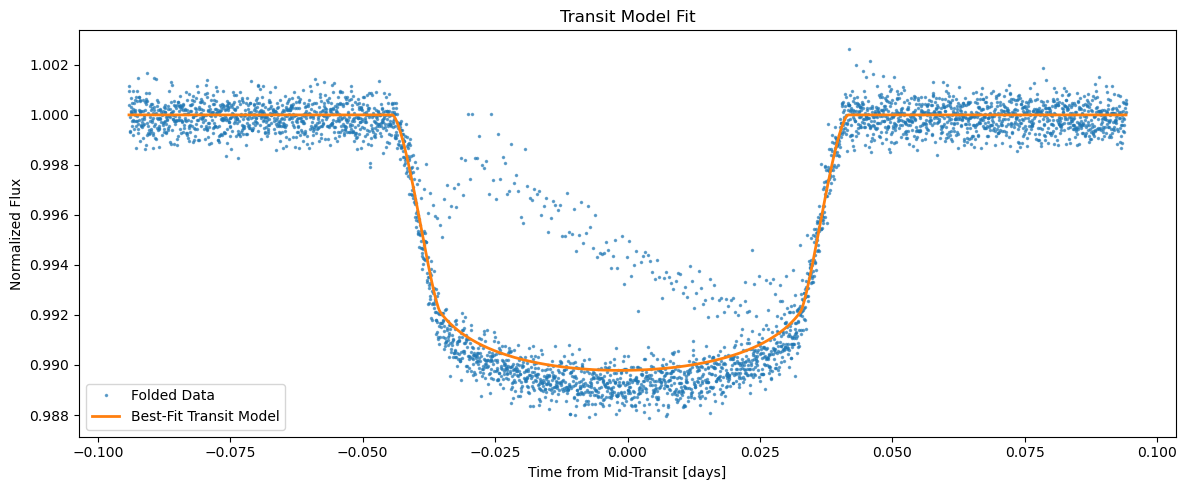

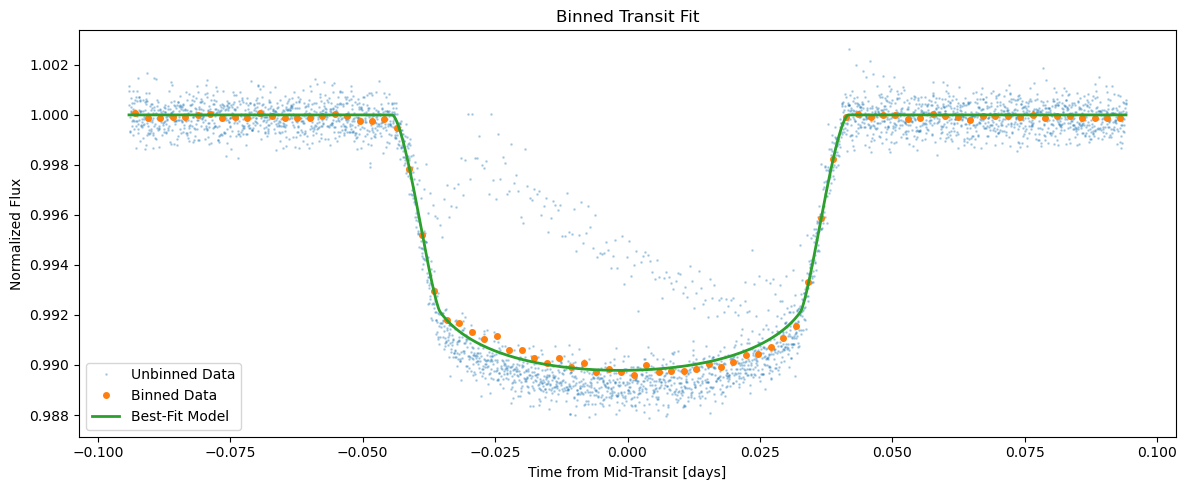


All figures were saved successfully in the 'figures' folder.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import matplotlib.pyplot as plt

import lightkurve as lk
from astropy.timeseries import BoxLeastSquares
import astropy.units as u

from scipy.optimize import curve_fit
import batman

# 1) TARGET
TARGET_NAME = "WASP-18"
MISSION = "TESS"

os.makedirs("figures", exist_ok=True)

# 2) DOWNLOAD TESS LIGHT CURVE
search_result = lk.search_lightcurve(TARGET_NAME, mission=MISSION)

if len(search_result) == 0:
    raise ValueError(f"No {MISSION} light curves found for target: {TARGET_NAME}")

lc = search_result.download()

print(f"Target: {TARGET_NAME}")
print("Light curve downloaded successfully.")

# 3) CLEANING + DETRENDING
lc_clean = lc.remove_nans().remove_outliers(sigma=5)
lc_flat = lc_clean.flatten(window_length=401).normalize()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(lc_clean.time.value, lc_clean.flux.value, ".", ms=1)
axes[0].set_title("Cleaned Light Curve")
axes[0].set_xlabel("Time [BTJD days]")
axes[0].set_ylabel("Flux")

axes[1].plot(lc_flat.time.value, lc_flat.flux.value, ".", ms=1)
axes[1].set_title("Detrended / Flattened Light Curve")
axes[1].set_xlabel("Time [BTJD days]")
axes[1].set_ylabel("Normalized Flux")

plt.tight_layout()
plt.savefig("figures/clean_lightcurve.png", dpi=300, bbox_inches="tight")
plt.show()

# 4) BLS TRANSIT SEARCH
time = lc_flat.time.value
flux = lc_flat.flux.value

if lc_flat.flux_err is not None:
    flux_err = lc_flat.flux_err.value
else:
    flux_err = np.full_like(flux, np.std(flux))

bls = BoxLeastSquares(time * u.day, flux, dy=flux_err)

period_grid = np.linspace(0.5, 1.5, 5000) * u.day
durations = np.linspace(0.05, 0.20, 10) * u.day

bls_power = bls.power(period_grid, durations)

best_index = np.argmax(bls_power.power)
best_period = bls_power.period[best_index].value
best_t0 = bls_power.transit_time[best_index].value
best_duration = bls_power.duration[best_index].value
best_depth = bls_power.depth[best_index]

print("\n=== BLS Results ===")
print(f"Best period   = {best_period:.6f} days")
print(f"Transit time  = {best_t0:.6f} BTJD")
print(f"Duration      = {best_duration:.6f} days")
print(f"Depth         = {best_depth:.6f}")

plt.figure(figsize=(12, 4))
plt.plot(bls_power.period.value, bls_power.power, "k-")
plt.axvline(best_period, color="r", linestyle="--", label=f"Best Period = {best_period:.4f} d")
plt.xlabel("Period [days]")
plt.ylabel("BLS Power")
plt.title("BLS Periodogram")
plt.legend()
plt.tight_layout()
plt.savefig("figures/bls_periodogram.png", dpi=300, bbox_inches="tight")
plt.show()

# 5) PHASE FOLDING
lc_fold = lc_flat.fold(period=best_period, epoch_time=best_t0)

plt.figure(figsize=(12, 5))
plt.plot(lc_fold.phase.value, lc_fold.flux.value, ".", ms=2, alpha=0.5)
plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.title("Phase-Folded Light Curve")
plt.tight_layout()
plt.savefig("figures/phase_folded.png", dpi=300, bbox_inches="tight")
plt.show()

# 6) PREPARE DATA FOR FITTING
phase = lc_fold.phase.value
fold_flux = lc_fold.flux.value

mask = np.abs(phase) < 0.10
phase_fit = phase[mask]
flux_fit = fold_flux[mask]

sort_idx = np.argsort(phase_fit)
phase_fit = phase_fit[sort_idx]
flux_fit = flux_fit[sort_idx]

t_fit = phase_fit * best_period

# 7) TRANSIT MODEL WITH BATMAN
def batman_model(t, rp, a_rs, inc, t0_shift):
    params = batman.TransitParams()
    params.t0 = t0_shift
    params.per = best_period
    params.rp = rp
    params.a = a_rs
    params.inc = inc
    params.ecc = 0.0
    params.w = 90.0
    params.u = [0.3, 0.2]
    params.limb_dark = "quadratic"

    model = batman.TransitModel(params, t)
    return model.light_curve(params)

rp_guess = np.sqrt(abs(best_depth))
p0 = [rp_guess, 10.0, 87.0, 0.0]

bounds = (
    [0.01,  2.0, 80.0, -0.02],
    [0.30, 50.0, 90.0,  0.02]
)

popt, pcov = curve_fit(
    batman_model,
    t_fit,
    flux_fit,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

rp_fit, a_rs_fit, inc_fit, t0_shift_fit = popt
perr = np.sqrt(np.diag(pcov))

print("\n=== Transit Fit Results ===")
print(f"Rp/Rs        = {rp_fit:.5f} ± {perr[0]:.5f}")
print(f"a/Rs         = {a_rs_fit:.5f} ± {perr[1]:.5f}")
print(f"Inclination  = {inc_fit:.5f} ± {perr[2]:.5f} deg")
print(f"t0 shift     = {t0_shift_fit:.6f} ± {perr[3]:.6f} days")
print(f"Transit depth≈ {rp_fit**2:.6f}")

# 8) PLOT BEST-FIT MODEL
t_model = np.linspace(t_fit.min(), t_fit.max(), 1000)
flux_model = batman_model(t_model, *popt)

plt.figure(figsize=(12, 5))
plt.plot(t_fit, flux_fit, ".", ms=3, alpha=0.6, label="Folded Data")
plt.plot(t_model, flux_model, "-", lw=2, label="Best-Fit Transit Model")
plt.xlabel("Time from Mid-Transit [days]")
plt.ylabel("Normalized Flux")
plt.title("Transit Model Fit")
plt.legend()
plt.tight_layout()
plt.savefig("figures/transit_fit.png", dpi=300, bbox_inches="tight")
plt.show()

# 9) BINNED PLOT
nbins = 80
bins = np.linspace(t_fit.min(), t_fit.max(), nbins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_flux = np.full(nbins, np.nan)

for i in range(nbins):
    in_bin = (t_fit >= bins[i]) & (t_fit < bins[i + 1])
    if np.any(in_bin):
        bin_flux[i] = np.mean(flux_fit[in_bin])

plt.figure(figsize=(12, 5))
plt.plot(t_fit, flux_fit, ".", ms=2, alpha=0.25, label="Unbinned Data")
plt.plot(bin_centers, bin_flux, "o", ms=4, label="Binned Data")
plt.plot(t_model, flux_model, "-", lw=2, label="Best-Fit Model")
plt.xlabel("Time from Mid-Transit [days]")
plt.ylabel("Normalized Flux")
plt.title("Binned Transit Fit")
plt.legend()
plt.tight_layout()
plt.savefig("figures/binned_transit_fit.png", dpi=300, bbox_inches="tight")
plt.show()


print("\nAll figures were saved successfully in the 'figures' folder.")